In [1]:
import numpy as np
import matplotlib.pyplot as plt

from causal_gym.envs.highway_single_step import HighwaySingleStepPCH

### Set up environment and demo functions

In [2]:
pch = HighwaySingleStepPCH()

In [3]:
def show_obs(obs, info):
    print('Observation of current state')
    print('X (velocity of driving car):\t\t', obs['x'])
    print('Z (velocity of front vehicle):\t\t', obs['z'])
    print('W (if car to the left is braking):\t', obs['w'])

In [4]:
def show_frame(frame):
    plt.imshow(frame)
    plt.axis('off')
    plt.show()

### Display observation and render frame

Observation of current state
X (velocity of driving car):		 25.0
Z (velocity of front vehicle):		 23.769263591706743
W (if car to the left is braking):	 0


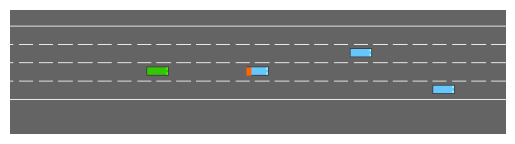

In [5]:
obs, info = pch.reset()
show_obs(obs, info)
show_frame(pch.render())

### SEE action taken by behavioral policy

Action observed:			 FASTER
Observation of current state
X (velocity of driving car):		 29.1455588268693
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0


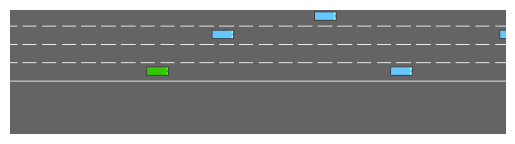

In [6]:
pch.reset()
action, obs, _, _, _, info = pch.see()
print('Action observed:\t\t\t', pch.env._meta_actions.ACTIONS_LONGI[action])
show_obs(obs, info)
show_frame(pch.render())

### DO intervention on X

Action taken:				 SLOWER
Observation of current state
X (velocity of driving car):		 20.8544411731307
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0


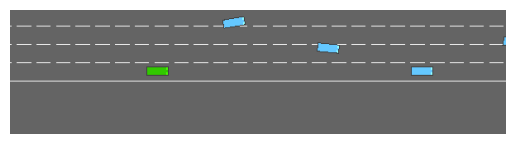

In [7]:
action = 0
pch.reset()
obs, _, _, _, info = pch.do(action)
print('Action taken:\t\t\t\t', pch.env._meta_actions.ACTIONS_LONGI[action])
show_obs(obs, info)
show_frame(pch.render())

### Raw output of obs and info

In [8]:
print('Raw output:')
pch.reset()

Raw output:


({'x': np.float64(25.0), 'z': 30.0, 'w': 0},
 {'u': 0,
  'l': 0,
  'y': None,
  'env_obs': array([[ 1.        ,  0.89106274,  0.5       ,  0.3125    ,  0.        ],
         [ 1.        ,  0.10762266, -0.5       , -0.01702784,  0.        ],
         [ 1.        ,  0.21107681, -0.25      , -0.02361498,  0.        ],
         [ 1.        ,  0.3149566 , -0.25      , -0.03388437,  0.        ],
         [ 1.        ,  0.4230127 ,  0.25      , -0.031644  ,  0.        ]],
        dtype=float32),
  'env_info': {'speed': 25,
   'crashed': False,
   'action': np.int64(0),
   'rewards': {'collision_reward': 0.0,
    'right_lane_reward': 0.6666666666666666,
    'high_speed_reward': np.float64(0.5),
    'on_road_reward': 1.0}}})

### Full single-step simulation using behavioral policy

Before:
Observation of current state
X (velocity of driving car):		 25.0
Z (velocity of front vehicle):		 22.45223232999931
W (if car to the left is braking):	 0
After:
Observation of current state
X (velocity of driving car):		 20.8544411731307
Z (velocity of front vehicle):		 21.673183779757363
W (if car to the left is braking):	 0


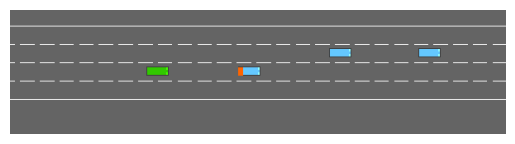

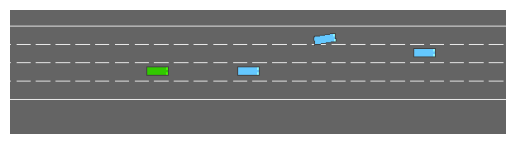

Action observed:	 SLOWER


In [9]:
obs, info = pch.reset()
print('Before:')
show_obs(obs, info)
before = pch.render()

action, obs, _, _, _, info = pch.see()
print('After:')
show_obs(obs, info)
after = pch.render()

show_frame(before)
show_frame(after)
print('Action observed:\t', pch.env._meta_actions.ACTIONS_LONGI[action])